# ENGR 1451/2451 — Weekly Assignment 5
**10 points**

Practice loading a CSV file, selecting complete observations, calculating correlations, making scatterplots and a correlation heat map, and writing a reusable function to compare individual and grouped data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

LE5-2 uses the supplied **`data/penguins.csv`** file. Keep the `data` folder beside this notebook. Use the folder containing the notebook as the working directory. The other exercises retain the embedded synthetic teaching data.

Select observations by conditions, not row positions. Calculate counts and cutoffs from the data. Label scatterplot axes with units. Keep written comments brief and tied to your calculated results.

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from IPython.display import display

## LE5-1. Compare laptop measurements (3 pts)

Each row describes one laptop. `battery_Wh` is battery capacity in watt-hours, `mass_kg` is mass in kilograms, and `runtime_h` is measured battery runtime in hours. Two entries are missing.

### A. Select complete observations (1 pt)

Create `complete` by selecting the three columns in `feature_cols` and dropping rows missing **any** of them. Report the number of laptops retained and excluded, using counts calculated from the data.

In [29]:
battery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,
              72, 75, 78, 84, 90, 96, np.nan, 80]
laptops = pd.DataFrame({
    "battery_Wh": battery_Wh,
    "mass_kg": [1.2, 1.1, 1.6, 1.2, 1.5, 1.3, 1.4, 1.8,
                1.5, 1.6, 1.9, 2.0, 1.7, 2.1, 1.8, 2.0],
    "runtime_h": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,
                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],
})
laptop_labels = {
    "battery_Wh": "Battery capacity (Wh)",
    "mass_kg": "Mass (kg)",
    "runtime_h": "Battery runtime (h)",
}
feature_cols = list(laptop_labels)
laptop_settings = {
    "lower_quantile": 0.25,
    "upper_quantile": 0.75,
}

# Your complete-case selection and retained/excluded counts here
complete = laptops[feature_cols].dropna()
num_retained = len(complete)
num_excluded = len(laptops)-num_retained

print(num_retained, "retained\n",
      num_excluded, "excluded")
complete.head()

14 retained
 2 excluded


,battery_Wh,mass_kg,runtime_h
0,36.0,1.2,4.1
1,42.0,1.1,6.0
2,45.0,1.6,5.4
3,48.0,1.2,7.6
4,54.0,1.5,6.5


### B. Plot a pair (1 pt)

Using `complete`, make a scatterplot of **battery capacity** on the x-axis and **runtime** on the y-axis. Calculate Pearson's $r$. Describe the direction and shape of the plotted association in one sentence.

**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).

r = 0.878


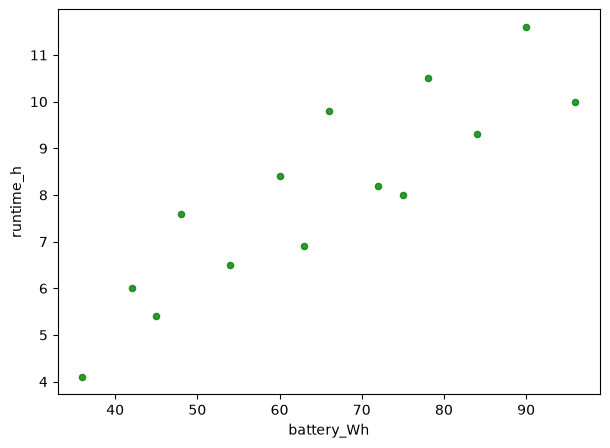

In [30]:
xcol = "battery_Wh"
ycol = "runtime_h"

# Your scatterplot and Pearson correlation here
ax = complete.plot.scatter(
    x=xcol,
    y=ycol,
    figsize=(7,5),
    alpha=0.8,
    color = "green",
)
complete_r = complete[xcol].corr(complete[ycol])
print("r =",round(complete_r,4))

### C. Restrict the range (1 pt)

Calculate the battery-capacity cutoffs at the quantiles specified in `laptop_settings`. Create `restricted` using `.loc[]` and `&` to keep capacities **between those cutoffs, including both endpoints**. Do not hard-code the cutoffs.

Display one table comparing the number of observations $n$ and the battery-capacity/runtime correlation $r$ for `complete` and `restricted`. Briefly report how $r$ changed.

**Answer:** The value of r for the restricted dataframe (r=0.438) is significantly less than the r for complete (r=0.878)

In [40]:
# Your data-derived cutoffs, Boolean filter, and n/r comparison here
battery_capacity_lower_cutoff = complete["battery_Wh"].quantile(laptop_settings["lower_quantile"])
battery_capacity_upper_cutoff = complete["battery_Wh"].quantile(laptop_settings["upper_quantile"])

mask_laptop_settings = (complete["battery_Wh"] > battery_capacity_lower_cutoff) & (complete["battery_Wh"] < battery_capacity_upper_cutoff)
restricted = complete[mask_laptop_settings]

restricted_r = restricted[xcol].corr(restricted[ycol])

comparison_table_LE5_1C = pd.DataFrame({
    "Number of observations": [len(complete),len(restricted)],
    "r": [complete_r,restricted_r]
},index = ["complete","restricted"])

comparison_table_LE5_1C.head()

,Number of observations,r
complete,14,0.878026
restricted,6,0.437600


## LE5-2. Cross-correlation matrix from a CSV file (3 pts)

Use the **Palmer Penguins** data in `data/penguins.csv`. Each row represents one penguin. Analyze the four physical measurements listed in `penguin_labels`; do not include species, island, sex, or year in the matrix.

Source: Horst, Hill, and Gorman, [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), with measurements collected by Kristen Gorman and Palmer Station LTER. [Variable definitions](https://allisonhorst.github.io/palmerpenguins/reference/penguins.html). The supplied CSV is the copy distributed with [plotnine](https://plotnine.org/reference/penguins.html); the data are licensed CC0. No additional package is needed to load the CSV.

### A. Load and prepare the data (1 pt)

Use `pd.read_csv()` to load `csv_path` into `penguins` and display its first few rows. Select `measurement_cols`, then drop rows missing **any of these four measurements**, storing the result as `penguin_complete`. Do not drop observations just because sex or another unused column is missing.

Report the number of rows loaded, retained, and excluded. Use the same `penguin_complete` observations throughout this exercise.

In [45]:
csv_path = Path("data/penguins.csv")
penguin_labels = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}
measurement_cols = list(penguin_labels)

# Your pd.read_csv(), preview, complete-case selection, and counts here
penguins = pd.read_csv(csv_path)
penguin_complete = penguins[measurement_cols].dropna()

rows_loaded = len(penguins)
rows_retained = len(penguin_complete)
rows_excluded = rows_loaded-rows_retained

print("Loaded:",rows_loaded,
      "\nRetained:",rows_retained,
      "\nExcluded:",rows_excluded)

penguins.head()

Loaded: 344 
Retained: 342 
Excluded: 2


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### B. Calculate and display the matrix (1 pt)

Calculate the **Pearson cross-correlation matrix** for all four columns of `penguin_complete` and name it `corr_matrix`. Here, the matrix contains the pairwise correlations between the measurement columns, not correlations at time lags. Display it rounded to three decimal places, keeping the unrounded matrix for plotting and subsequent calculations.

**The heat-map code is provided below; do not rewrite it.** Run the function-definition cell, then use `ax = plot_correlation_heatmap(corr_matrix)` after calculating your matrix. The fixed scale maps **−1 to dark red, 0 to white, and +1 to dark blue**.

In [ ]:
# Provided plotting code: run this cell unchanged.
def plot_correlation_heatmap(corr_matrix):
    """Plot the student's matrix on a fixed red–white–blue scale."""
    cmap = LinearSegmentedColormap.from_list(
        "correlation_rwb", ["darkred", "white", "darkblue"], N=257
    )  # An odd palette size makes the middle color exactly white.

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(
        corr_matrix, cmap=cmap, vmin=-1, vmax=1, interpolation="nearest"
    )
    positions = np.arange(len(corr_matrix.columns))
    labels = [penguin_labels[column] for column in corr_matrix.columns]
    ax.set_xticks(positions, labels=labels, rotation=45, ha="right")
    ax.set_yticks(positions, labels=labels)
    ax.set_title("Palmer Penguins: Pearson correlation matrix", pad=14)

    for (row, col), value in np.ndenumerate(corr_matrix.to_numpy()):
        ax.text(
            col, row, f"{value:.2f}", ha="center", va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

    fig.colorbar(image, ax=ax, label="Pearson r", ticks=[-1, -0.5, 0, 0.5, 1])
    fig.tight_layout()
    plt.show()
    return ax

In [ ]:
# Your corr_matrix calculation and rounded display here

# After calculating corr_matrix, uncomment the following line:
# ax = plot_correlation_heatmap(corr_matrix)

### C. Select pairs and make a scatterplot (1 pt)

Use your matrix to identify the **strongest positive** and **strongest negative** correlations between distinct measurements. Ignore the diagonal and count each pair only once. Report both pairs and retrieve their correlations with `.loc[]`, rather than typing the correlation values by hand.

Make a scatterplot for whichever of these two pairs has the larger absolute correlation. Label the axes using `penguin_labels` and include its $r$ in the title.

In [ ]:
# Identify the two pairs and retrieve their r values from corr_matrix.
# Plot the pair with the larger absolute correlation.

## LE5-3. Compare a curved pattern with an added observation (2 pts)

A process-development team records product yield at several temperatures. Each row is one run. `yield_pct` is the percentage of starting material recovered as the desired product.

### A. Plot the original runs (1 pt)

Plot temperature on the x-axis and yield on the y-axis, then calculate Pearson's $r$. Use a condition on `yield_pct` to display the run or runs with the highest observed yield. Briefly describe the plotted pattern.

**Answer:**

In [ ]:
runs = pd.DataFrame({
    "temperature_C": [30, 35, 40, 45, 50, 55, 60, 65, 70],
    "yield_pct": [31, 48, 72, 88, 95, 86, 70, 50, 32],
})

# Your scatterplot, Pearson correlation, and maximum-yield run selection here

### B. Add one unusual observation (1 pt)

Use `pd.concat()` to combine `runs` and `extra_run` into a new DataFrame, `all_runs`; retain the original data.

Display one table comparing $n$ and $r$ for the original and combined data. Make a scatterplot of the combined data, marking the additional run with a different marker and adding a legend. Report the numerical change in $r$ (combined minus original).

In [ ]:
extra_run = pd.DataFrame({"temperature_C": [130], "yield_pct": [5]})

# Your combined data, n/r comparison, and scatterplot here

## LE5-4. Write a function and use it twice (2 pts)

Each row below is one trainee in one of four workshops. The records give practice hours and an assembly assessment score on a 0–100 scale. These are synthetic observational records.

### A. Write and call your function (1 pt)

The individual and workshop-average analyses require the same scatterplot, count, and correlation. Write **`plot_and_summarize(data, title)`** to do that work once in a reusable function.

Your function must:

1. Create and display a **new scatterplot** of `practice_hours` on the x-axis and `assembly_score` on the y-axis. Label the axes **Practice hours (h)** and **Assembly score (0–100)**, and use the supplied `title`.
2. Calculate the number of rows $n$ and Pearson's $r$ from the supplied `data`.
3. **Return a `pd.Series`** with entries named `"n"` and `"r"`, rather than only printing them.

Use the `data` argument for every calculation and plot; do not refer to `trainees` or `workshop_means` inside the function. Do not hard-code the row count or correlation.

**First call:** Call your function on `trainees` with the title `"Individual trainees"`. Store its returned Series as `individual_summary` and display it. Write both the function body and the call yourself.

In [ ]:
trainees = pd.DataFrame({
    "workshop": ["A"] * 5 + ["B"] * 5 + ["C"] * 5 + ["D"] * 5,
    "practice_hours": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,
                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],
    "assembly_score": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,
                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],
})

def plot_and_summarize(data, title):
    """Plot practice hours versus score and return a Series containing n and r."""
    # Write your function body here.
    pass


# First call: analyze trainees and store the result as individual_summary.
# Display the returned Series.

### B. Reuse the function for workshop averages (1 pt)

Use `.groupby(...).agg(...)` to create `workshop_means`, with one row per workshop showing its trainee count, mean practice hours, and mean assembly score. Name the count column `trainee_count`, and keep the two mean columns named **`practice_hours`** and **`assembly_score`** so the same function can analyze them. Display this table.

**Second call:** Call the **same function** on `workshop_means` with the title `"Workshop averages"`. Store its returned Series as `workshop_summary`. The returned $n$ now counts workshop rows, not individual trainees.

Use `individual_summary` and `workshop_summary` to create one labeled comparison table containing $n$ and $r$. Do not duplicate the scatterplot or correlation code outside the function. Briefly report how $r$ changed after aggregation.

**Answer:**

In [ ]:
# Create and display workshop_means using .groupby(...).agg(...).
# Keep the mean-column names practice_hours and assembly_score.

# Second call: analyze workshop_means and store the result as workshop_summary.

# Combine the two returned Series into a labeled n/r comparison table.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 1,
  "session_date": "2026-10-04",
  "messages": [
    {"i": 1, "who": "student", "text": "For LE5 A\n\n```python\ncomplete = laptops[feature_cols].dropna()\nnum_retained = complete.count()\nnum_excluded = laptops.count()-num_retained\n\nprint(num_retained, \"retained\\n\",\n      num_excluded, \"excluded\")\ncomplete.head()\n```\n\nIs there a way to get the .count() function (or use a different function) to solely count the number of rows/observations overall instead of for each column?", "code": true},
    {"i": 2, "who": "tutor", "text": "Explained that `.count()` is column-wise (counts non-missing values per column), while `len(df)` or `df.shape[0]` give a single total row count. Gave a toy example contrasting the two, and asked the student to apply this to get the retained/excluded counts."},
    {"i": 3, "who": "student", "text": "That worked, thanks!"},
    {"i": 4, "who": "tutor", "text": "Confirmed the fix (swapping in a row-count function instead of a per-column one) and asked whether to continue with LE5-1A or move to part B."},
    {"i": 5, "who": "student", "text": "Can you outline the different scatter plot commands from all the different libraries covered so far in the course?"},
    {"i": 6, "who": "tutor", "text": "Outlined `ax.scatter()`, `ax.plot()` used with `linestyle=\"none\"`, and pandas' `.plot.scatter()`, with syntax examples and the tradeoffs of each, noting `ax.scatter()` via `plt.subplots()` is the one the course's assignments call for. Offered to show two `ax.scatter()` calls sharing one legend."},
    {"i": 7, "who": "student", "text": "Does this sentance effectively describe direction and shape of association? \n\n```markdown\n**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).\n```"},
    {"i": 8, "who": "tutor", "text": "Verified r = 0.878 against `complete` (n=14) via a reference calculation, confirmed the sentence satisfies the direction-and-shape requirement, and suggested the student double-check that the scatterplot itself (not just the r value) supports the \"linear\" claim before finalizing."},
    {"i": 9, "who": "student", "text": "How can I call the quantile values from the laptop settings dictionary?"},
    {"i": 10, "who": "tutor", "text": "Explained dictionary key access (`some_dict[\"key\"]`) with a toy example, noted the two keys `\"lower_quantile\"` and `\"upper_quantile\"` in `laptop_settings`, and asked if the student wanted `.quantile()` explained next or was ready to combine the pieces."},
    {"i": 11, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "5-1A", "type": "code"},
    {"i": 2, "part": "5-1A", "type": "explain"},
    {"i": 3, "part": "5-1A", "type": "part_pass"},
    {"i": 8, "part": "5-1B", "type": "part_pass"},
    {"i": 9, "part": "5-1C", "type": "explain"}
  ],
  "parts": [
    {"part": "5-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "5-1B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "5-1C", "exchanges": 1, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "No real sticking point this session — the .count()-vs-row-count mixup on 5-1A resolved in one exchange, and the 5-1B answer check passed on the first try.",
    "No escape-hatch or release-valve use this session; progress looked student-driven throughout."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.